# Diabetic Retinopathy Blur Robustness Study

This notebook tests how diabetic retinopathy classifiers behave when retinal images become progressively blurred. The main question is not whether the models reach state-of-the-art accuracy, but whether their predictions and visual attention degrade in a consistent way from B0 clean images to B4 strong blur. This first code cell imports the libraries, fixes the random seed, and sets the plotting style.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

TensorFlow : 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Dataset And Experiment Settings

The dataset is loaded from Kaggle with train, validation, and test folders. FAST_MODE uses a smaller balanced sample because free Kaggle GPU time is limited, so the results should be read as indicative rather than final population estimates.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

Dataset           : /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2
Models            : ['CNN', 'ResNet50', 'DenseNet201', 'EfficientNetB0']
Epochs head/fine  : 10 / 20
LR head/fine      : 0.001 / 2e-05
Loss              : weighted categorical cross-entropy


## Manifest Collection

The manifest records each image path, class label, split, and a filename-based patient/eye guess. The patient and eye fields are best-effort values because they are inferred from filenames rather than a separate verified patient table.


Total images: 92501


,path,split,label,class_name,file_name,patient_id_guess,eye_guess
0,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,train,0,No DR,005b95c28852.jpg,005b95c28852,unknown
1,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,train,0,No DR,0097f532ac9f.jpg,0097f532ac9f,unknown
2,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,train,0,No DR,00cc2b75cddd.jpg,00cc2b75cddd,unknown
3,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,train,0,No DR,00f6c1be5a33.jpg,00f6c1be5a33,unknown
4,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,train,0,No DR,0125fbd2e791.jpg,0125fbd2e791,unknown


class_name,Mild,Moderate,No DR,Proliferative DR,Severe
split,,,,,
test,466,1518,6896,253,128
train,3706,12119,55162,2002,1006
val,462,1514,6895,249,125


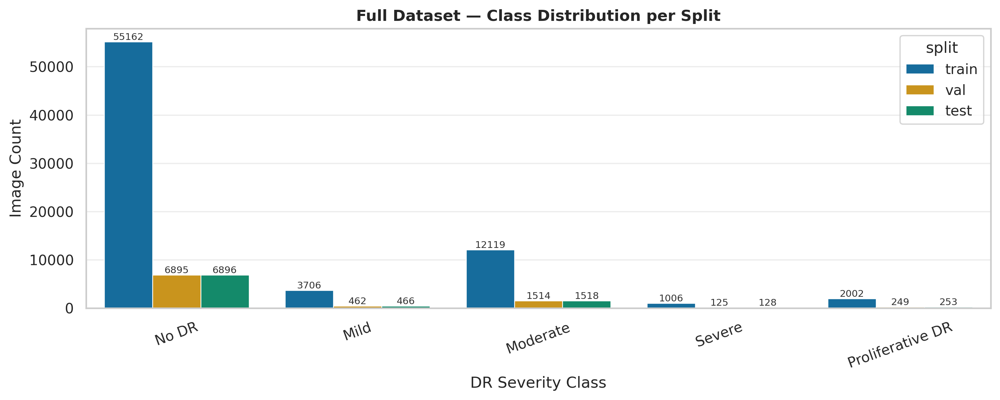

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Class Balance And Leakage Check

The class distribution shows the imbalance in the selected training, validation, and test samples. The patient overlap check is a best-effort leakage check using the guessed patient ID, so it reduces leakage risk but cannot fully prove patient independence.


Train: 7006  |  Val: 1574  |  Test: 1581


class_name,Mild,Moderate,No DR,Proliferative DR,Severe
label,,,,,
0,0,0,1500,0,0
1,1500,0,0,0,0
2,0,1500,0,0,0
3,0,0,0,0,1006
4,0,0,0,1500,0


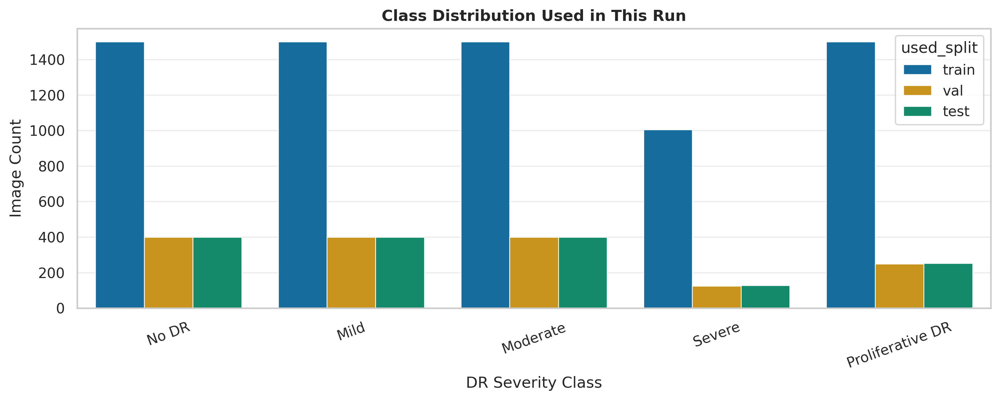

Best-effort patient ID overlap check:
  train vs val : 340 overlapping guessed IDs
  train vs test: 319 overlapping guessed IDs
  val vs test  : 75 overlapping guessed IDs
Note: patient IDs are guessed from filenames, so this reduces leakage risk but cannot fully prove patient independence.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Blur Levels

B0 is the clean baseline. B1 to B4 apply increasing Gaussian blur. The blur sigma values were calibrated for roughly 300 px images, but here they are applied after resizing to 224 px, which is noted as a limitation.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

,code,display,sigma,meaning
0,B0,0%,0.0,clean
1,B1,20%,1.0,weak blur
2,B2,40%,2.0,mild blur
3,B3,60%,3.0,moderate blur
4,B4,80%,4.0,strong blur


B5 or 100 percent blur is excluded because it may remove too much retinal information to be practically meaningful.
Note: sigma values were calibrated for approximately 300 px images, then applied after resizing to 224 px.


## Preprocessing And Class Weights

Images are cropped, padded, resized, and optionally blurred. Class weights are computed from the training set so minority disease grades matter during training.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

I0000 00:00:1788070904.090665      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788070904.093635      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights: {0: '0.934', 1: '0.934', 2: '0.934', 3: '1.393', 4: '0.934'}


## Visual Blur Check

This montage gives a simple visual check that the same preprocessing pipeline produces increasing blur from B0 to B4.


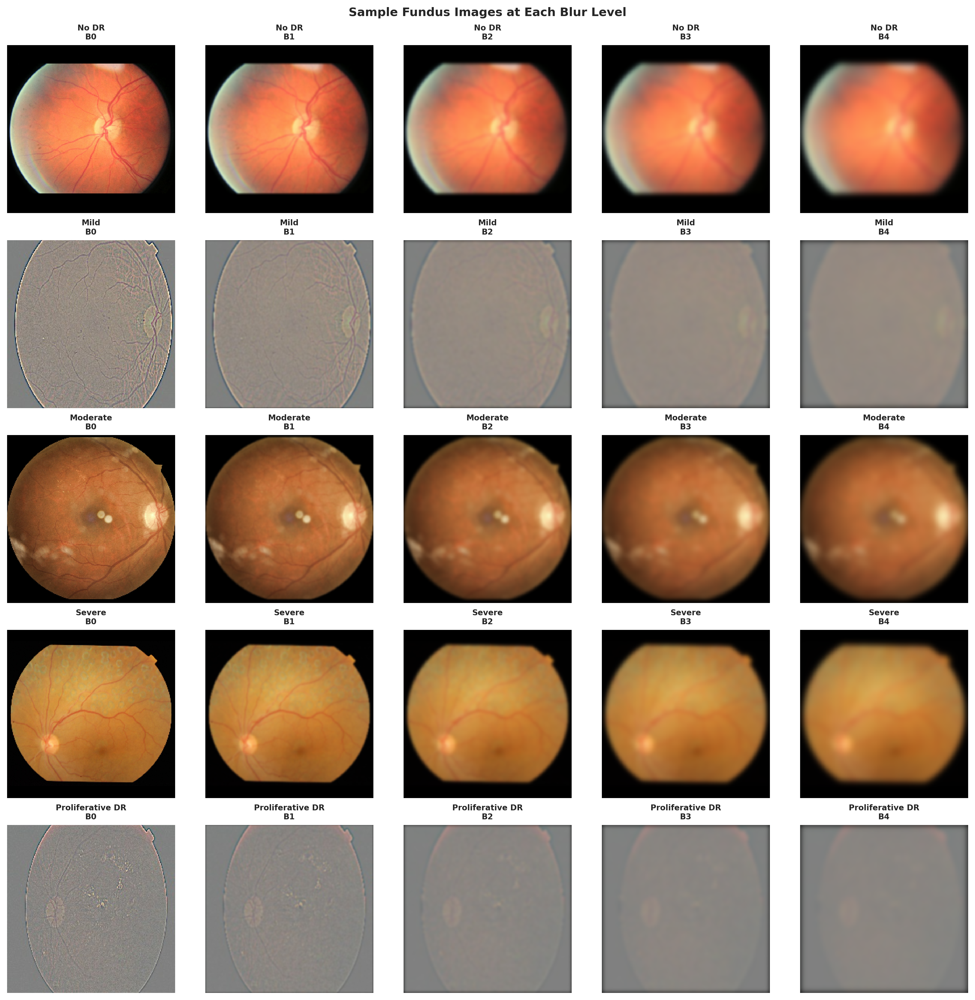

,blur,sigma,mean,std
0,B0,0.0,100.000000,0.000000
1,B1,1.0,34.086217,3.749951
2,B2,2.0,30.509322,3.428745
3,B3,3.0,28.731012,3.248335
4,B4,4.0,27.513742,3.144480


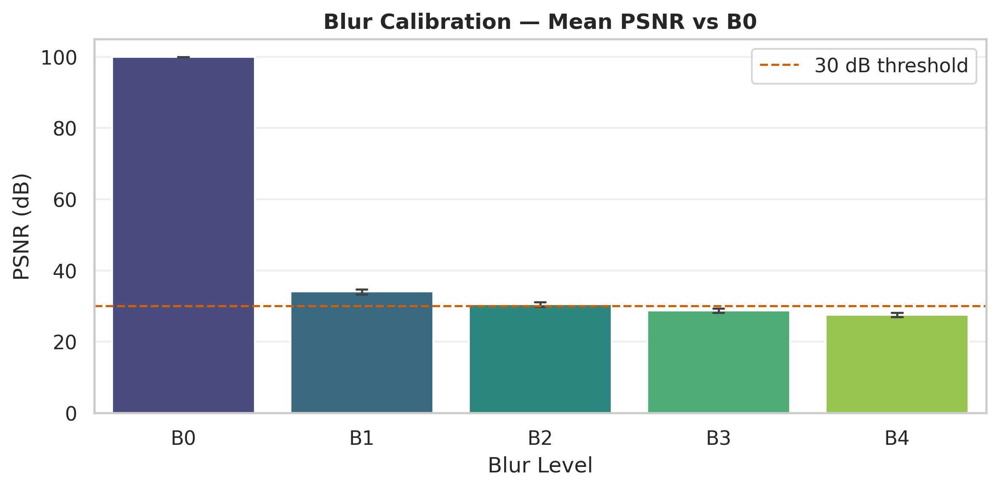

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Sharpness Check

Variance of the Laplacian is used as a sharpness score. A higher value means the image has stronger edges and is sharper. This supports the assumption that B0 images are usable as a clean baseline, and the falling values across B1-B4 independently confirm that the blur pipeline works.


,blur,sigma,median_laplacian_variance,mean_laplacian_variance,min_laplacian_variance,max_laplacian_variance
0,B0,0.0,342.12,572.88,5.85,4534.85
1,B1,1.0,21.48,32.71,0.67,251.91
2,B2,2.0,5.32,8.99,0.34,54.41
3,B3,3.0,3.21,4.92,0.30,23.80
4,B4,4.0,2.56,3.51,0.28,14.32


B0 median sharpness: 342.12
Expected pattern: Laplacian variance should fall from B0 to B4 as blur increases.
Boxplot whiskers show the full min-to-max range; if a blur level has a narrow range, the numeric table above should be used with the plot.


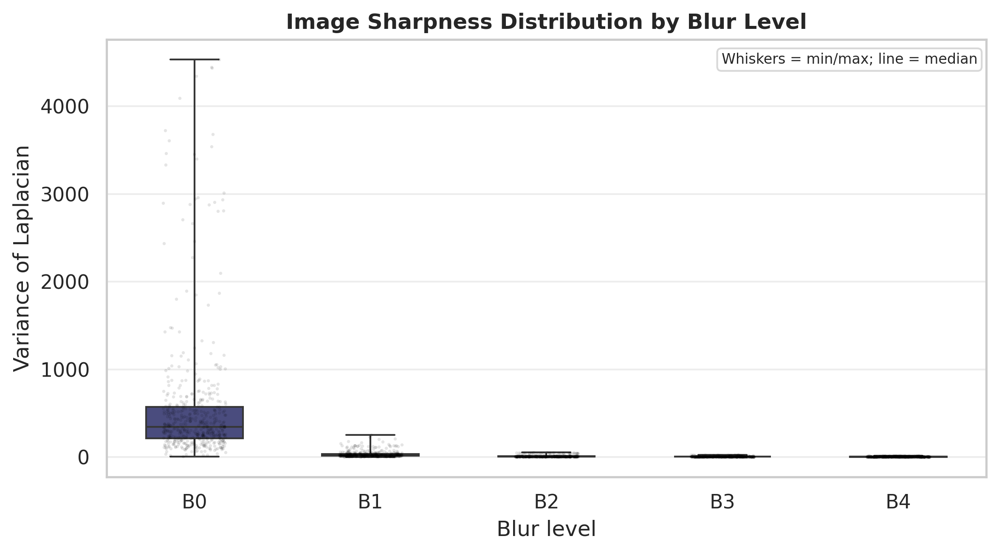

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Models And Training Choices


The final hyperparameters were selected as a conservative configuration after small pilot runs rather than a full grid search. Because Kaggle free-tier GPU time is limited, I did not exhaustively test every combination. The CNN settings were chosen by comparing a few practical alternatives for depth, dropout, learning rate, and augmentation strength, then keeping the configuration that gave the best validation behaviour without obvious overfitting. The transfer-learning models use the same head, dropout, optimizer, and two-stage schedule so the robustness comparison remains fair across architectures.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

,Area,Final setting,Alternatives considered
0,Input,"224 x 224, batch size 32",Smaller image sizes and batch sizes were consi...
1,CNN depth,"4 convolution blocks: 32, 64, 128, 256 filters",Shallower CNNs underfit; adding more blocks in...
2,Dense head,CNN: Dense(128); transfer models: Dense(256),Larger heads were avoided because the dataset ...
3,Dropout,0.35,Pilot settings around 0.25 to 0.50 were consid...
4,Optimizer,Adam with clipnorm=1.0,Adam was retained for stable convergence; grad...
5,Learning rates,head/CNN 0.001; fine-tuning 2e-05,Higher fine-tuning rates risked damaging Image...
6,Epochs and stopping,"head 10, fine-tune 20, early stopping on val_loss",The epoch limits are maximums; early stopping ...
7,Augmentation,"horizontal flip, rotation 0.10, zoom 0.10, tra...",Vertical flips were excluded as clinically unr...


CNN hyperparameter note: only a limited pilot comparison was performed, not a full exhaustive grid/random search.
Final CNN configuration was selected for the best validation behaviour among practical settings under Kaggle time limits.


## Training And Blur Evaluation

Each model is trained on clean images, then tested on B0-B4. This measures relative robustness: how much performance is retained as blur increases.



Training: CNN
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 152s 646ms/step - accuracy: 0.2144 - loss: 1.6924 - val_accuracy: 0.2541 - val_loss: 1.7941 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 599ms/step - accuracy: 0.2379 - loss: 1.6073 - val_accuracy: 0.2294 - val_loss: 1.6131 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 622ms/step - accuracy: 0.2466 - loss: 1.5978 - val_accuracy: 0.1912 - val_loss: 1.6319 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.2635 - loss: 1.5785
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
219/219 ━━━━━━━━━━━━━━━━━━━━ 138s 629ms/step - accuracy: 0.2516 - loss: 1.5844 - val_accuracy: 0.1779 - val_loss: 1.6164 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 135s 617ms/step - accuracy: 0.2524 - loss: 1.5758 - val_accuracy: 0.2656 - val_loss: 1.5474 - learning_rate: 3.0000e-04
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 617

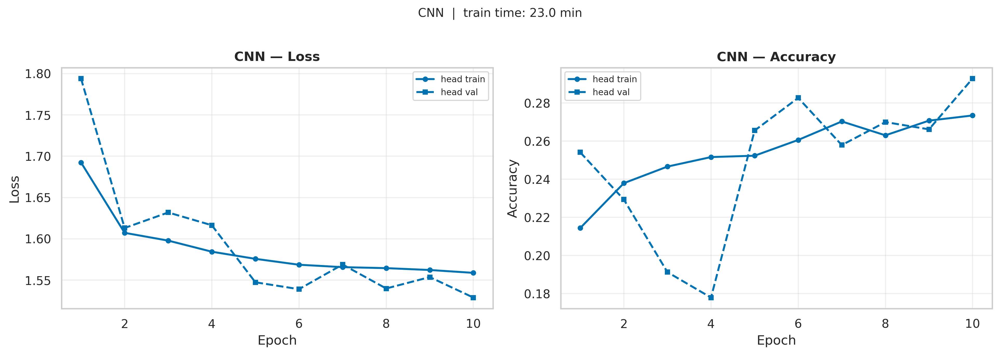

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 580ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 855ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 239s 5s/step

Training: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 150s 640ms/step - accuracy: 0.3524 - loss: 1.6311 - val_accuracy: 0.3596 - val_loss: 1.5630 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 627ms/step - accuracy: 0.4005 - loss: 1.3836 - val_accuracy: 0.3310 - val_loss: 1.5074 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 619ms/step - accuracy: 0.4256 - loss: 1.3109 - val_accuracy: 0.3844 - val_loss: 1.3321 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 135s 613ms/step - accuracy: 0.4375 - loss: 1.2815 - val_accuracy: 0.4117 - val_loss: 1.2912 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 633ms/step - accuracy: 0.4498 - loss: 1.2633 - val_accura

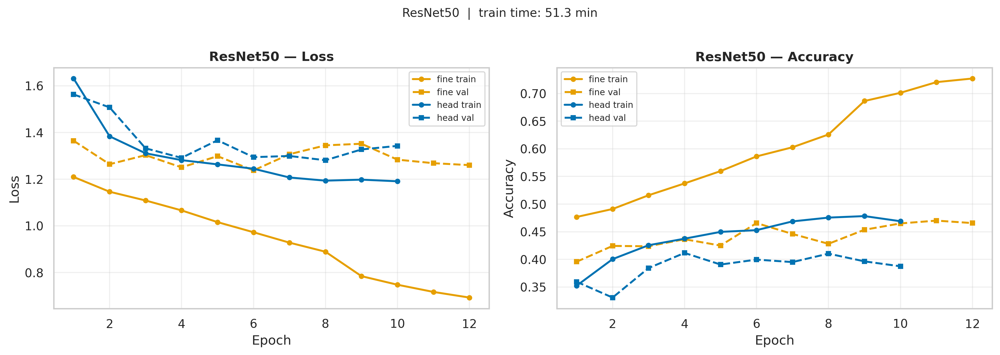

50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 521ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 885ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 238s 5s/step

Training: DenseNet201
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 180s 707ms/step - accuracy: 0.3611 - loss: 1.5962 - val_accuracy: 0.4091 - val_loss: 1.3557 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 142s 647ms/step - accuracy: 0.4105 - loss: 1.3727 - val_accuracy: 0.4098 - val_loss: 1.3193 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 656ms/step - accuracy: 0.4259 - loss: 1.3070 - val_accuracy: 0.3723 - val_loss: 1.3936 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.4474 - loss: 1.2723
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 657ms/step - accuracy: 0.4440 - loss: 1.2728 - val_accura

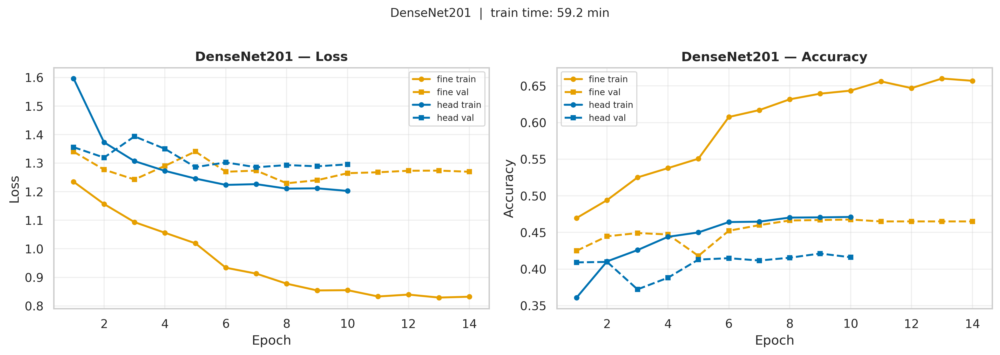

50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 652ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 894ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 243s 5s/step

Training: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


E0000 00:00:1788080774.304369      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


219/219 ━━━━━━━━━━━━━━━━━━━━ 151s 640ms/step - accuracy: 0.3537 - loss: 1.6683 - val_accuracy: 0.3691 - val_loss: 1.4584 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 622ms/step - accuracy: 0.3957 - loss: 1.4183 - val_accuracy: 0.3774 - val_loss: 1.3794 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 135s 616ms/step - accuracy: 0.4179 - loss: 1.3310 - val_accuracy: 0.4199 - val_loss: 1.2744 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 136s 619ms/step - accuracy: 0.4265 - loss: 1.3008 - val_accuracy: 0.3482 - val_loss: 1.4525 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4492 - loss: 1.2745
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
219/219 ━━━━━━━━━━━━━━━━━━━━ 138s 629ms/step - accuracy: 0.4411 - loss: 1.2845 - val_accuracy: 0.4009 - val_loss: 1.3187 - learning_rate: 0.0010
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 633ms/step - accuracy: 0.4535 - l

E0000 00:00:1788082165.404818      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


219/219 ━━━━━━━━━━━━━━━━━━━━ 161s 654ms/step - accuracy: 0.4596 - loss: 1.2256 - val_accuracy: 0.4238 - val_loss: 1.2632 - learning_rate: 2.0000e-05
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 631ms/step - accuracy: 0.4794 - loss: 1.1896 - val_accuracy: 0.4250 - val_loss: 1.2445 - learning_rate: 2.0000e-05
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 624ms/step - accuracy: 0.4949 - loss: 1.1586 - val_accuracy: 0.4282 - val_loss: 1.2424 - learning_rate: 2.0000e-05
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 626ms/step - accuracy: 0.4903 - loss: 1.1512 - val_accuracy: 0.4492 - val_loss: 1.2037 - learning_rate: 2.0000e-05
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 140s 638ms/step - accuracy: 0.4939 - loss: 1.1295 - val_accuracy: 0.4454 - val_loss: 1.2287 - learning_rate: 2.0000e-05
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.5026 - loss: 1.1214
Epoch 6: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-06.
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 634ms/step - 

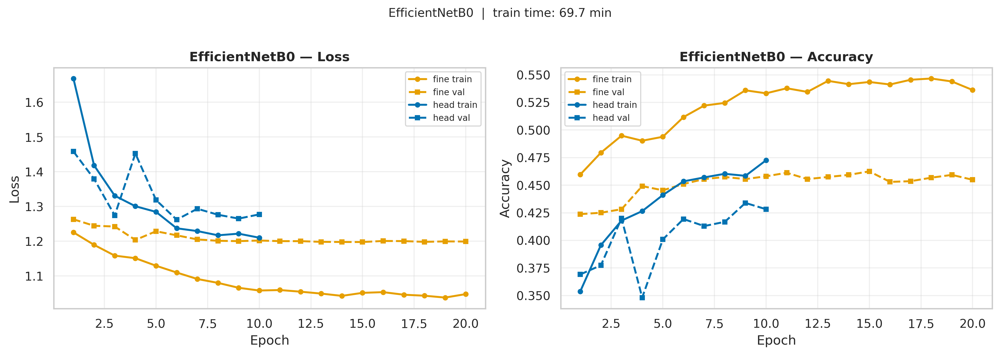

50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 539ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 928ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 241s 5s/step


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,qwk,mean_absolute_grade_error,off_by_one_accuracy,under_grading_rate,over_grading_rate,macro_roc_auc_ovr,micro_roc_auc_ovr,model,blur,display_blur,sigma,training_minutes,parameters,inference_sec_per_image
0,0.2865,0.2746,0.2591,0.2746,0.2211,0.2076,1.4700,0.5636,0.4807,0.2328,0.6022,0.6441,CNN,B0,0%,0.0,22.9760,423877,0.0186
1,0.2397,0.2816,0.2573,0.2816,0.2311,0.2231,1.4706,0.5629,0.2309,0.5294,0.5990,0.5678,CNN,B1,20%,1.0,22.9760,423877,0.0272
2,0.1809,0.2514,0.2619,0.2514,0.1790,0.1477,1.5149,0.5446,0.1664,0.6528,0.5818,0.4928,CNN,B2,40%,2.0,22.9760,423877,0.0544
3,0.1727,0.2472,0.2830,0.2472,0.1684,0.1307,1.5092,0.5389,0.1575,0.6698,0.5702,0.4745,CNN,B3,60%,3.0,22.9760,423877,0.0955
4,0.1720,0.2395,0.2826,0.2395,0.1656,0.1187,1.4864,0.5497,0.1676,0.6603,0.5663,0.4726,CNN,B4,80%,4.0,22.9760,423877,0.1513
5,0.4978,0.5184,0.5174,0.5184,0.4951,0.6804,0.7173,0.8419,0.2650,0.2372,0.8109,0.8201,ResNet50,B0,0%,0.0,51.2582,24114565,0.0186
6,0.4358,0.4755,0.4227,0.4755,0.4260,0.6030,0.8874,0.7571,0.2498,0.3144,0.7814,0.7857,ResNet50,B1,20%,1.0,51.2582,24114565,0.0282
7,0.2745,0.3111,0.3266,0.3111,0.2311,0.2177,1.6679,0.4706,0.1297,0.5958,0.6847,0.6107,ResNet50,B2,40%,2.0,51.2582,24114565,0.0556
8,0.1860,0.2257,0.2939,0.2257,0.1090,0.0365,2.2138,0.2910,0.0228,0.7913,0.6190,0.5284,ResNet50,B3,60%,3.0,51.2582,24114565,0.0958
9,0.1720,0.2115,0.3634,0.2115,0.0838,0.0090,2.3011,0.2600,0.0145,0.8134,0.5764,0.5029,ResNet50,B4,80%,4.0,51.2582,24114565,0.1508


,class,class_name,sensitivity,specificity,model,blur,sigma
0,0,No DR,0.7125,0.4564,CNN,B0,0.0
1,1,Mild,0.1125,0.8967,CNN,B0,0.0
2,2,Moderate,0.0200,0.9814,CNN,B0,0.0
3,3,Severe,0.1484,0.9394,CNN,B0,0.0
4,4,Proliferative DR,0.3794,0.8087,CNN,B0,0.0
...,...,...,...,...,...,...,...
95,0,No DR,0.5300,0.6029,EfficientNetB0,B4,4.0
96,1,Mild,0.0925,0.9399,EfficientNetB0,B4,4.0
97,2,Moderate,0.1475,0.8518,EfficientNetB0,B4,4.0
98,3,Severe,0.0234,0.9952,EfficientNetB0,B4,4.0


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Clean-Image Classification Reports

These reports show how each model performs on B0 before artificial blur is added.



  MODEL: CNN  —  B0 (Clean Images)
                  precision    recall  f1-score   support

           No DR       0.31      0.71      0.43       400
            Mild       0.27      0.11      0.16       400
        Moderate       0.27      0.02      0.04       400
          Severe       0.18      0.15      0.16       128
Proliferative DR       0.27      0.38      0.32       253

        accuracy                           0.29      1581
       macro avg       0.26      0.27      0.22      1581
    weighted avg       0.27      0.29      0.22      1581



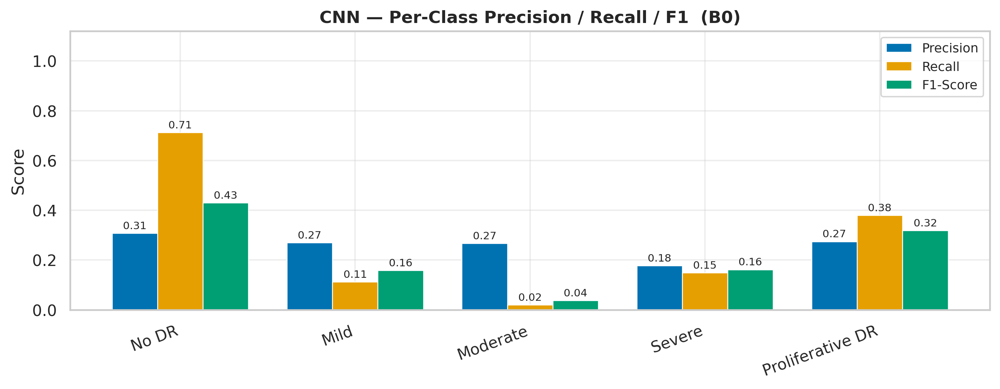


  MODEL: ResNet50  —  B0 (Clean Images)
                  precision    recall  f1-score   support

           No DR       0.49      0.49      0.49       400
            Mild       0.42      0.59      0.49       400
        Moderate       0.58      0.21      0.31       400
          Severe       0.50      0.48      0.49       128
Proliferative DR       0.60      0.82      0.69       253

        accuracy                           0.50      1581
       macro avg       0.52      0.52      0.50      1581
    weighted avg       0.51      0.50      0.48      1581



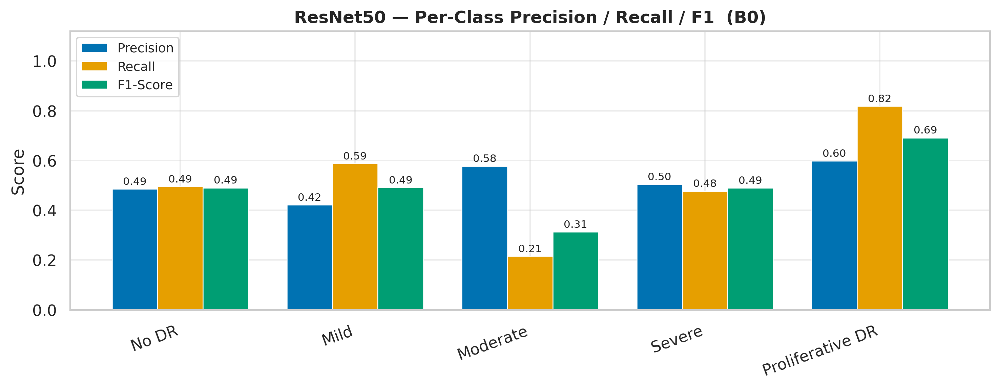


  MODEL: DenseNet201  —  B0 (Clean Images)
                  precision    recall  f1-score   support

           No DR       0.45      0.52      0.48       400
            Mild       0.41      0.57      0.48       400
        Moderate       0.58      0.13      0.22       400
          Severe       0.41      0.47      0.43       128
Proliferative DR       0.59      0.77      0.67       253

        accuracy                           0.47      1581
       macro avg       0.49      0.49      0.46      1581
    weighted avg       0.49      0.47      0.44      1581



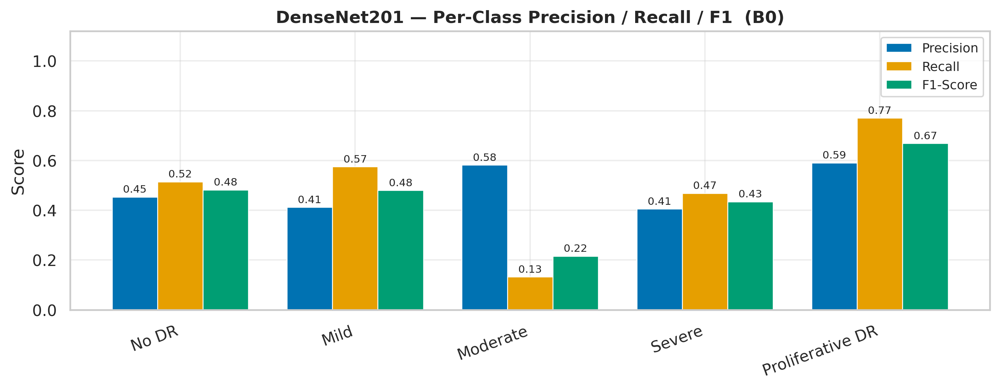


  MODEL: EfficientNetB0  —  B0 (Clean Images)
                  precision    recall  f1-score   support

           No DR       0.48      0.52      0.50       400
            Mild       0.41      0.54      0.47       400
        Moderate       0.47      0.22      0.30       400
          Severe       0.35      0.64      0.46       128
Proliferative DR       0.72      0.57      0.64       253

        accuracy                           0.47      1581
       macro avg       0.49      0.50      0.47      1581
    weighted avg       0.49      0.47      0.46      1581



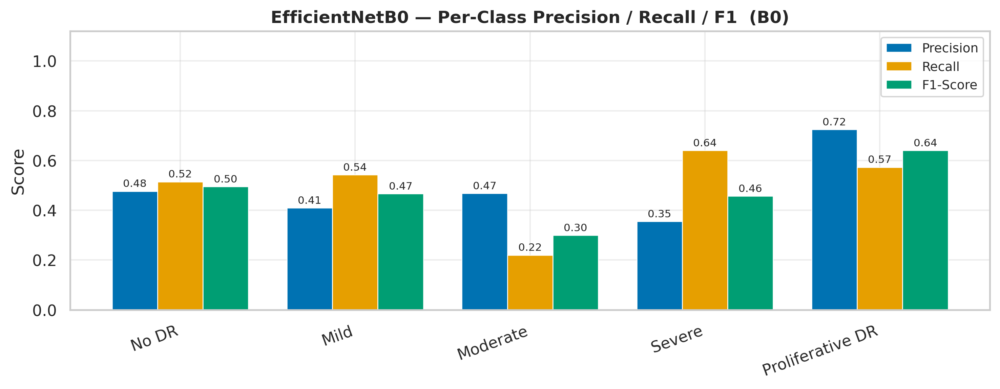

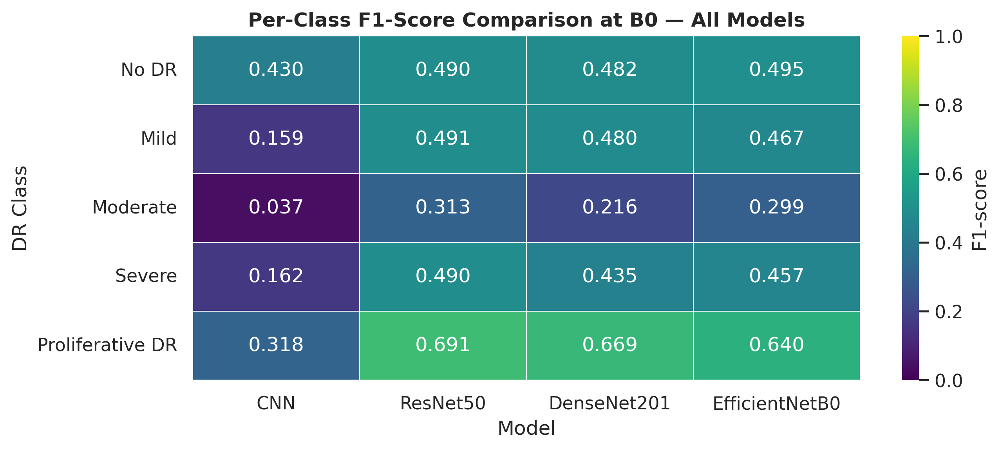

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Robustness Table

The robustness table compares each blur level with that model's own B0 score. This is important because the project focuses on degradation, not only raw accuracy.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

,model,blur,sigma,macro_f1,macro_f1_absolute_drop,macro_f1_relative_retention,qwk,qwk_absolute_drop,macro_roc_auc_ovr,macro_auc_absolute_drop
0,CNN,B0,0.0,0.2211,0.0000,1.0000,0.2076,0.0000,0.6022,0.0000
1,CNN,B1,1.0,0.2311,-0.0100,1.0453,0.2231,-0.0154,0.5990,0.0032
2,CNN,B2,2.0,0.1790,0.0422,0.8093,0.1477,0.0599,0.5818,0.0203
3,CNN,B3,3.0,0.1684,0.0528,0.7614,0.1307,0.0769,0.5702,0.0320
4,CNN,B4,4.0,0.1656,0.0555,0.7488,0.1187,0.0889,0.5663,0.0359
5,ResNet50,B0,0.0,0.4951,0.0000,1.0000,0.6804,0.0000,0.8109,0.0000
6,ResNet50,B1,1.0,0.4260,0.0691,0.8604,0.6030,0.0774,0.7814,0.0295
7,ResNet50,B2,2.0,0.2311,0.2640,0.4668,0.2177,0.4627,0.6847,0.1263
8,ResNet50,B3,3.0,0.1090,0.3862,0.2201,0.0365,0.6439,0.6190,0.1919
9,ResNet50,B4,4.0,0.0838,0.4114,0.1692,0.0090,0.6714,0.5764,0.2346


,model,metric,degradation_slope,area_under_degradation_curve
0,CNN,accuracy,-0.02960,0.20565
1,CNN,balanced_accuracy,-0.01046,0.25934
2,CNN,macro_f1,-0.01738,0.19295
3,CNN,qwk,-0.02702,0.16615
4,CNN,macro_roc_auc_ovr,-0.01005,0.58382
5,DenseNet201,accuracy,-0.07147,0.32954
6,DenseNet201,balanced_accuracy,-0.06910,0.36914
7,DenseNet201,macro_f1,-0.08550,0.29887
8,DenseNet201,qwk,-0.16647,0.35439
9,DenseNet201,macro_roc_auc_ovr,-0.05961,0.70720


## Statistical Tests

ANOVA and Kruskal-Wallis are exploratory here. The expanded analysis uses class-level performance values, so each blur group contains five observations, one for each DR class. Sensitivity is still included, but the section now also reports specificity, precision, and F1-score so the conclusion is not based on sensitivity alone.

Global metrics such as macro F1, QWK, and ROC-AUC are shown in the robustness tables and curves, but they are not used as ANOVA outcomes here because there is only one global value per model and blur level. The p-value threshold is alpha = 0.05; significant values are marked with an asterisk in the Sig. column.


,model,blur,sigma,class,class_name,sensitivity,specificity,precision,f1_score
0,CNN,B0,0.0,0,No DR,0.7125,0.4564,0.3074,0.4295
1,CNN,B0,0.0,1,Mild,0.1125,0.8967,0.2695,0.1587
2,CNN,B0,0.0,2,Moderate,0.0200,0.9814,0.2667,0.0372
3,CNN,B0,0.0,3,Severe,0.1484,0.9394,0.1776,0.1617
4,CNN,B0,0.0,4,Proliferative DR,0.3794,0.8087,0.2743,0.3184
5,CNN,B1,1.0,0,No DR,0.2850,0.8586,0.4057,0.3348
6,CNN,B1,1.0,1,Mild,0.1650,0.8603,0.2857,0.2092
7,CNN,B1,1.0,2,Moderate,0.0700,0.9204,0.2295,0.1073
8,CNN,B1,1.0,3,Severe,0.4297,0.7020,0.1127,0.1786
9,CNN,B1,1.0,4,Proliferative DR,0.4585,0.7417,0.2527,0.3258


ANOVA 1 - Model Effect on B0 Class-Level Metrics


,Dependent Variable,Grouping Variable,Source,Sum of Squares,df,Mean Square,F,Sig.
0,Sensitivity,Model,Between Groups,0.1976,3,0.0659,1.2864,0.3130
1,Sensitivity,Model,Within Groups,0.8192,16,0.0512,,
2,Sensitivity,Model,Total,1.0168,19,,,


,Dependent Variable,Grouping Variable,Source,Sum of Squares,df,Mean Square,F,Sig.
0,Specificity,Model,Between Groups,0.0092,3,0.0031,0.1678,0.9165
1,Specificity,Model,Within Groups,0.2911,16,0.0182,,
2,Specificity,Model,Total,0.3003,19,,,


,Dependent Variable,Grouping Variable,Source,Sum of Squares,df,Mean Square,F,Sig.
0,Precision,Model,Between Groups,0.2165,3,0.0722,8.0383,0.0017*
1,Precision,Model,Within Groups,0.1436,16,0.0090,,
2,Precision,Model,Total,0.3601,19,,,


...

,Model,Dependent Variable,Grouping Variable,Source,Sum of Squares,df,Mean Square,F,Sig.
0,EfficientNetB0,Precision,Blur Level,Between Groups,0.1429,4,0.0357,3.3174,0.0307*
1,EfficientNetB0,Precision,Blur Level,Within Groups,0.2154,20,0.0108,,
2,EfficientNetB0,Precision,Blur Level,Total,0.3583,24,,,


,Model,Dependent Variable,Context,(I) Group,(J) Group,Mean Difference (I-J),Sig.,Lower Bound,Upper Bound
0,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B0,B1,-0.0297,0.9906,-0.2261,0.1667
1,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B0,B2,-0.0762,0.7728,-0.2726,0.1202
2,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B0,B3,-0.1526,0.1779,-0.3490,0.0438
3,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B0,B4,-0.2030*,0.0407*,-0.3994,-0.0066
4,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B1,B2,-0.0464,0.9523,-0.2428,0.1500
5,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B1,B3,-0.1229,0.3629,-0.3193,0.0735
6,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B1,B4,-0.1732,0.1005,-0.3696,0.0232
7,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B2,B3,-0.0765,0.7705,-0.2728,0.1199
8,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B2,B4,-0.1268,0.3336,-0.3232,0.0696
9,EfficientNetB0,Precision,EfficientNetB0 blur comparison,B3,B4,-0.0503,0.9372,-0.2467,0.1461


,Model,Dependent Variable,Grouping Variable,Source,Sum of Squares,df,Mean Square,F,Sig.
0,EfficientNetB0,F1-score,Blur Level,Between Groups,0.2621,4,0.0655,3.7794,0.0190*
1,EfficientNetB0,F1-score,Blur Level,Within Groups,0.3467,20,0.0173,,
2,EfficientNetB0,F1-score,Blur Level,Total,0.6087,24,,,


,Model,Dependent Variable,Context,(I) Group,(J) Group,Mean Difference (I-J),Sig.,Lower Bound,Upper Bound
0,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B0,B1,-0.0317,0.9952,-0.2808,0.2175
1,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B0,B2,-0.1183,0.6225,-0.3674,0.1309
2,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B0,B3,-0.2245,0.0902,-0.4737,0.0247
3,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B0,B4,-0.2597*,0.0385*,-0.5089,-0.0105
4,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B1,B2,-0.0866,0.8340,-0.3358,0.1626
5,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B1,B3,-0.1928,0.1810,-0.4420,0.0563
6,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B1,B4,-0.2280,0.0830,-0.4772,0.0211
7,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B2,B3,-0.1062,0.7083,-0.3554,0.1429
8,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B2,B4,-0.1415,0.4568,-0.3906,0.1077
9,EfficientNetB0,F1-score,EfficientNetB0 blur comparison,B3,B4,-0.0352,0.9928,-0.2844,0.2140



Footnote: * p < 0.05. ANOVA uses class-level values, n = 5 DR classes per blur level.
Tukey HSD post-hoc tables are shown only when the corresponding ANOVA is significant and statsmodels is available.


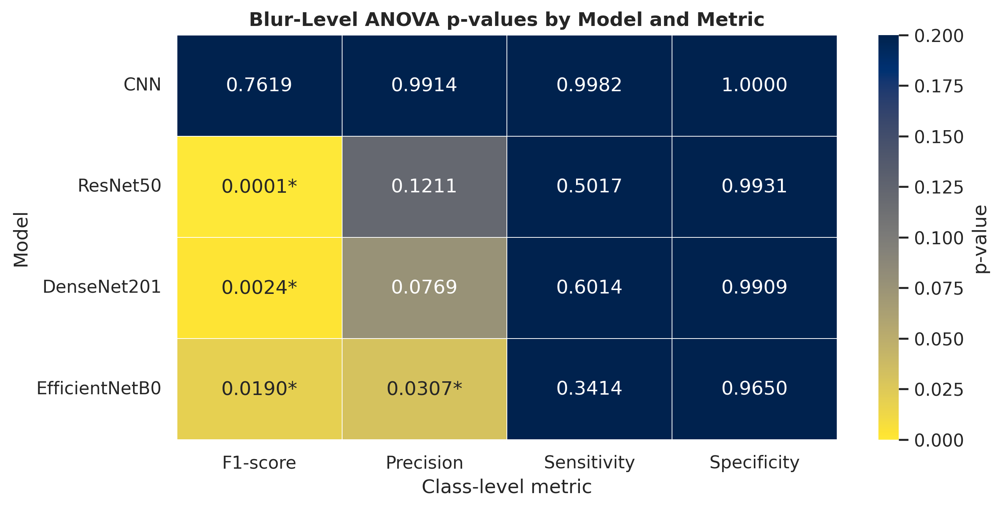

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Robustness Curves

The curves are the clearest way to show whether model performance declines smoothly as blur increases.


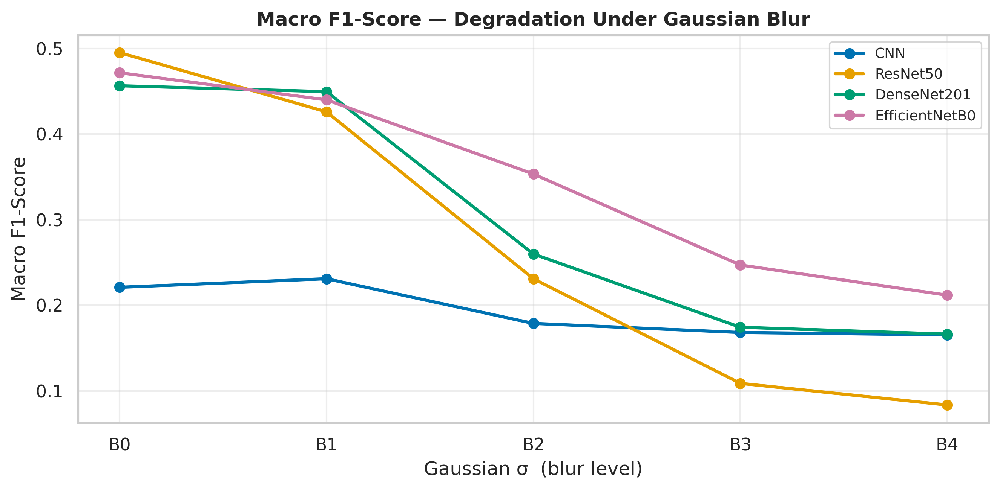

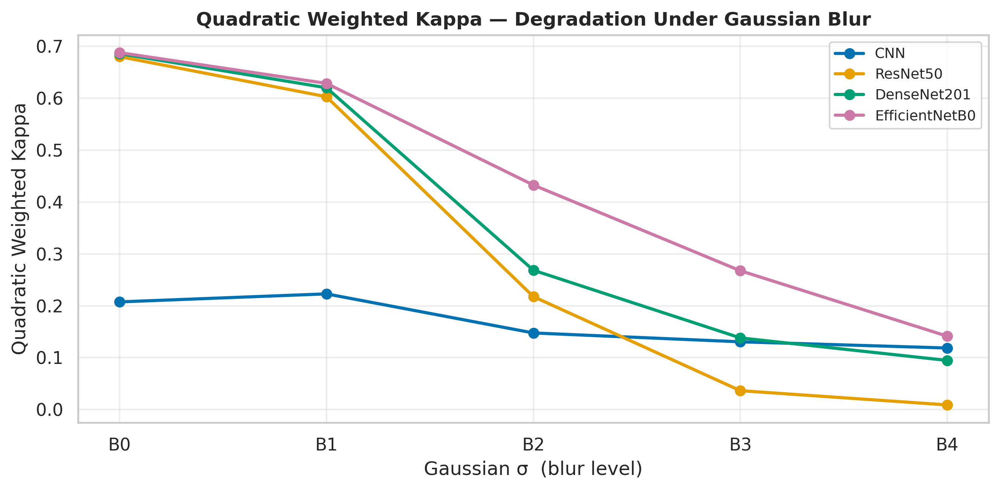

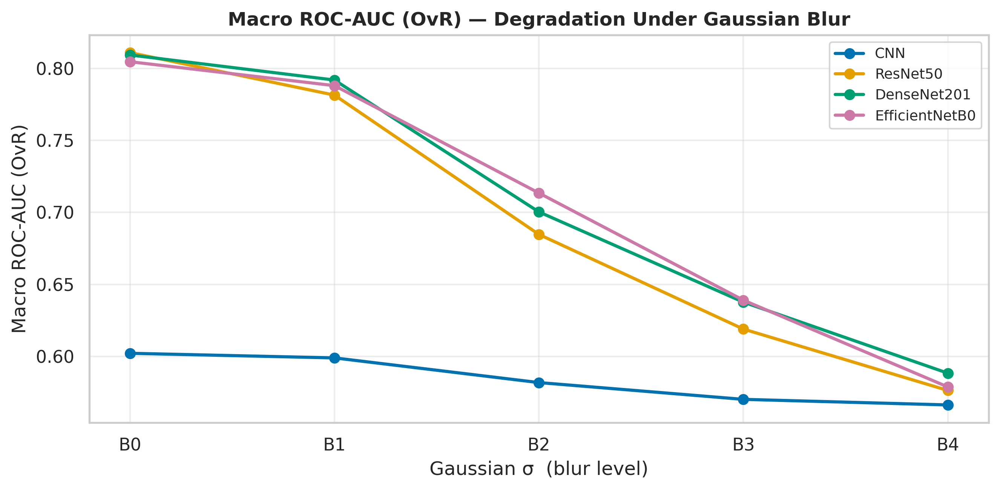

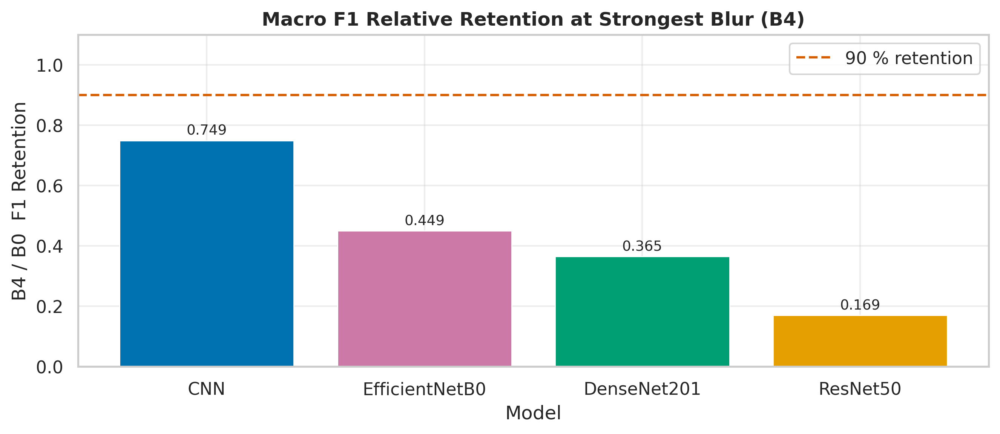

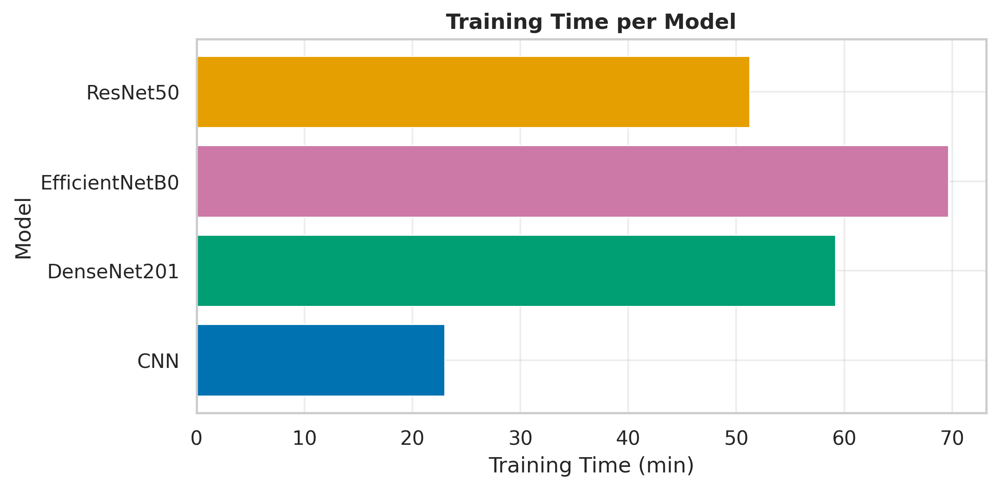

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Confusion Matrices

The confusion matrices show which disease grades are confused as image quality gets worse.


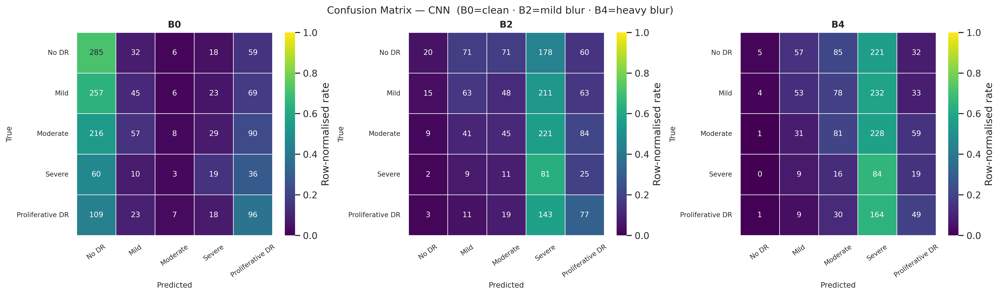

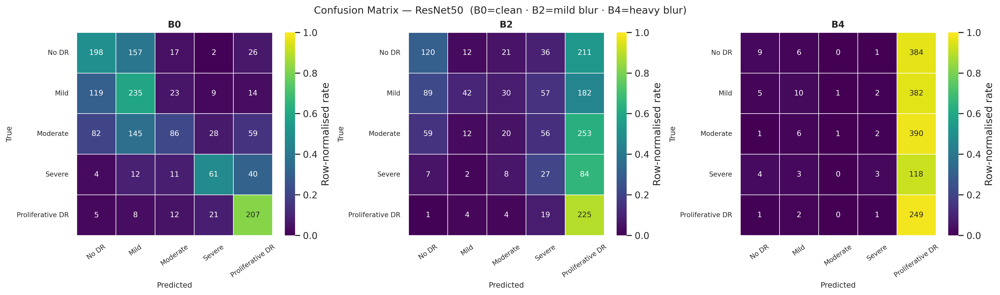

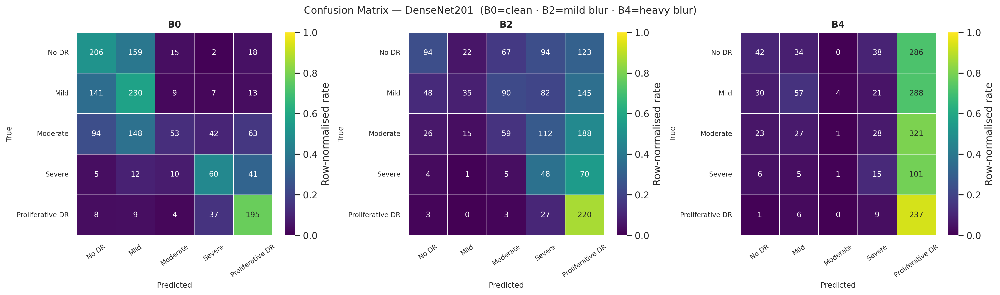

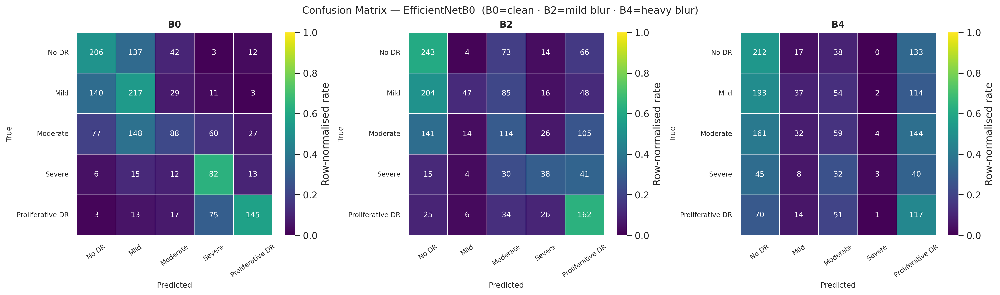

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## ROC Curves

ROC-AUC on B0 gives another clean-image performance view before the blur stress test.


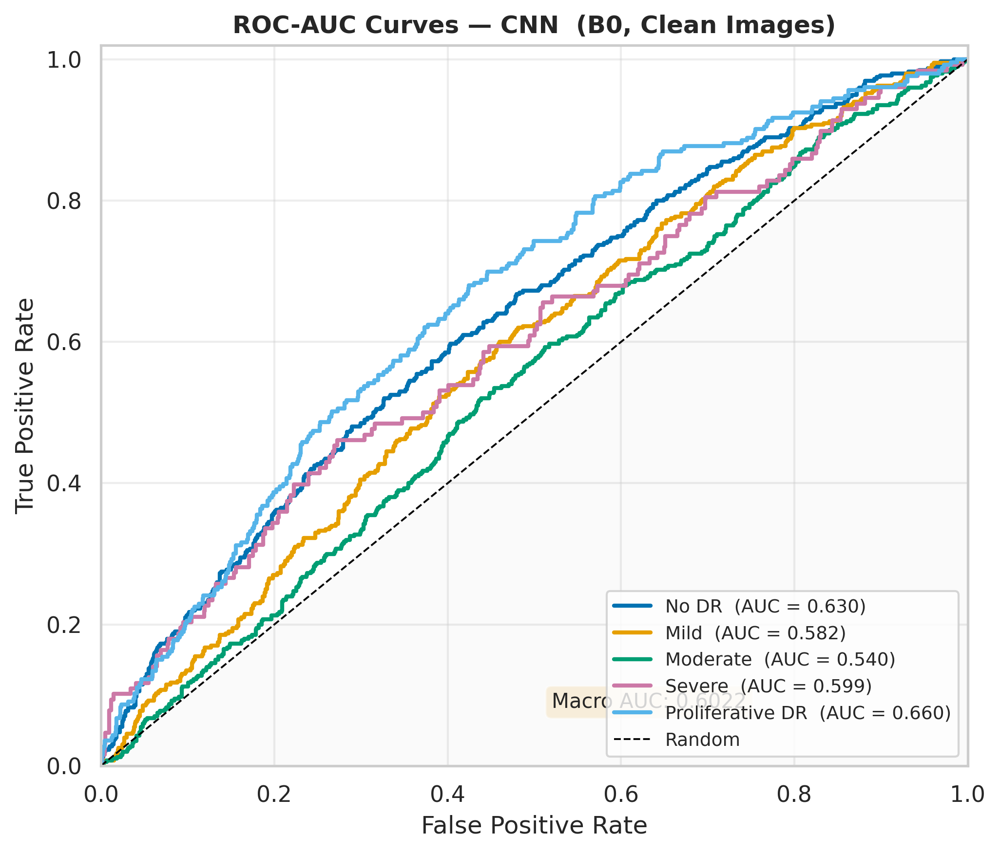

  CNN  — per-class AUC:  No DR=0.630  Mild=0.582  Moderate=0.540  Severe=0.599  Proliferative DR=0.660
  Macro AUC: 0.6022



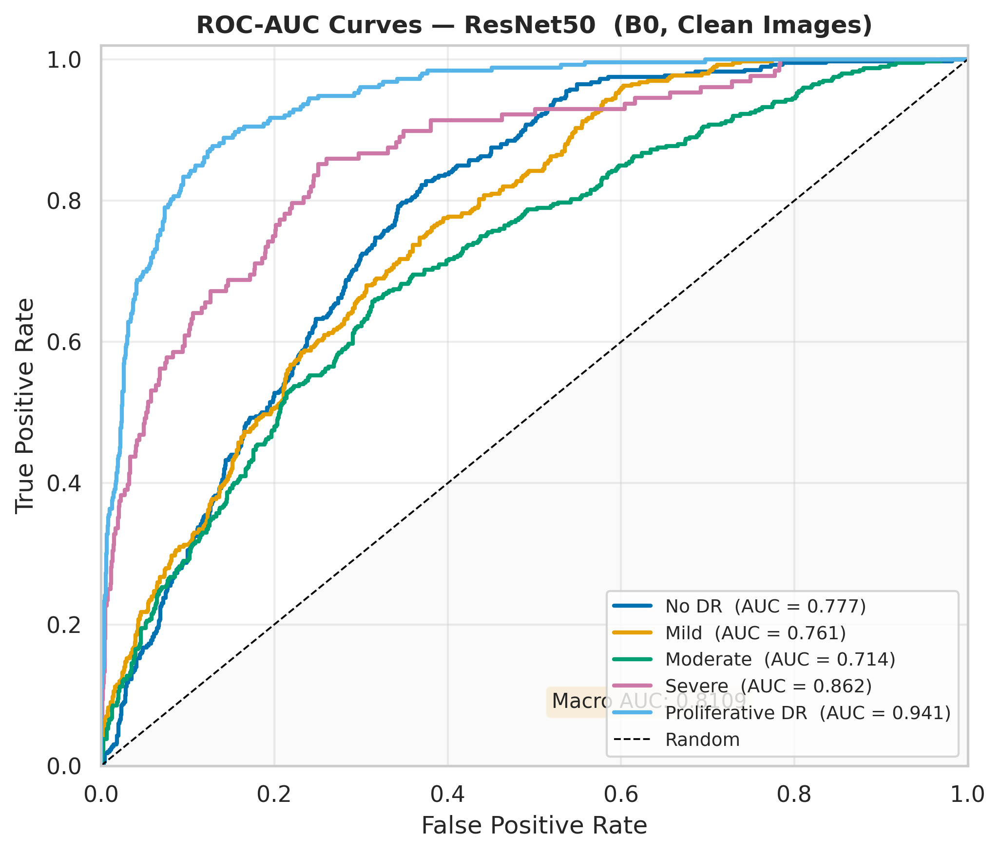

  ResNet50  — per-class AUC:  No DR=0.777  Mild=0.761  Moderate=0.714  Severe=0.862  Proliferative DR=0.941
  Macro AUC: 0.8109



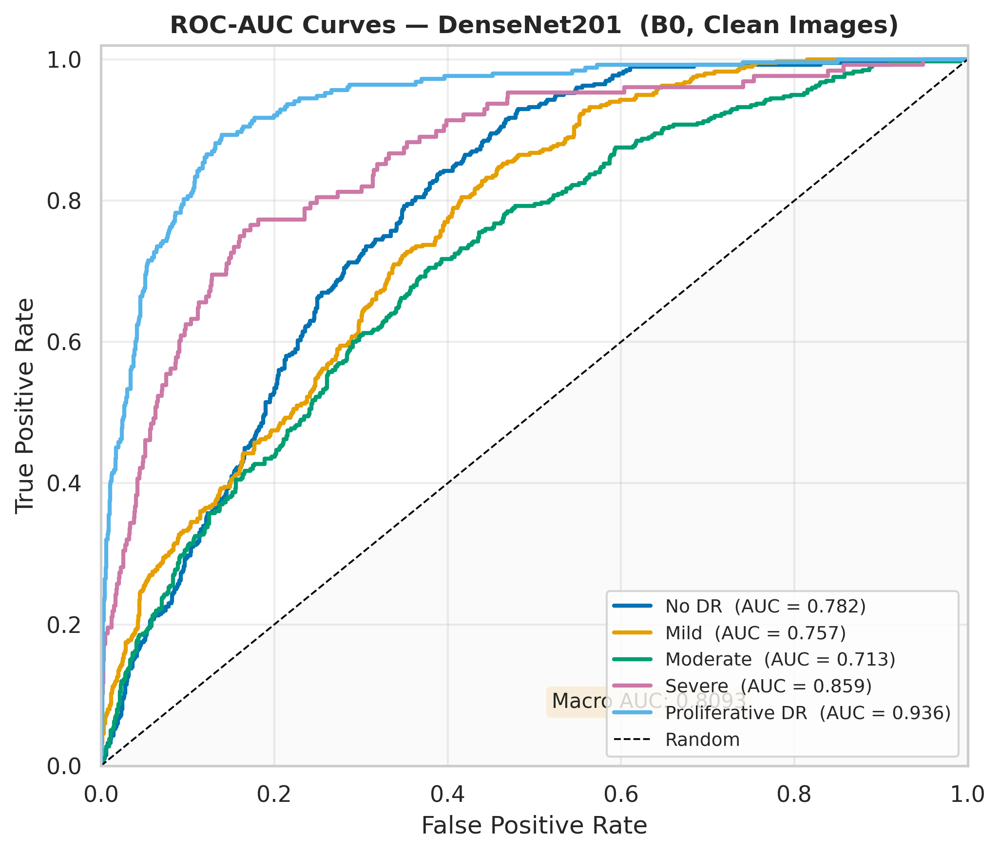

  DenseNet201  — per-class AUC:  No DR=0.782  Mild=0.757  Moderate=0.713  Severe=0.859  Proliferative DR=0.936
  Macro AUC: 0.8093



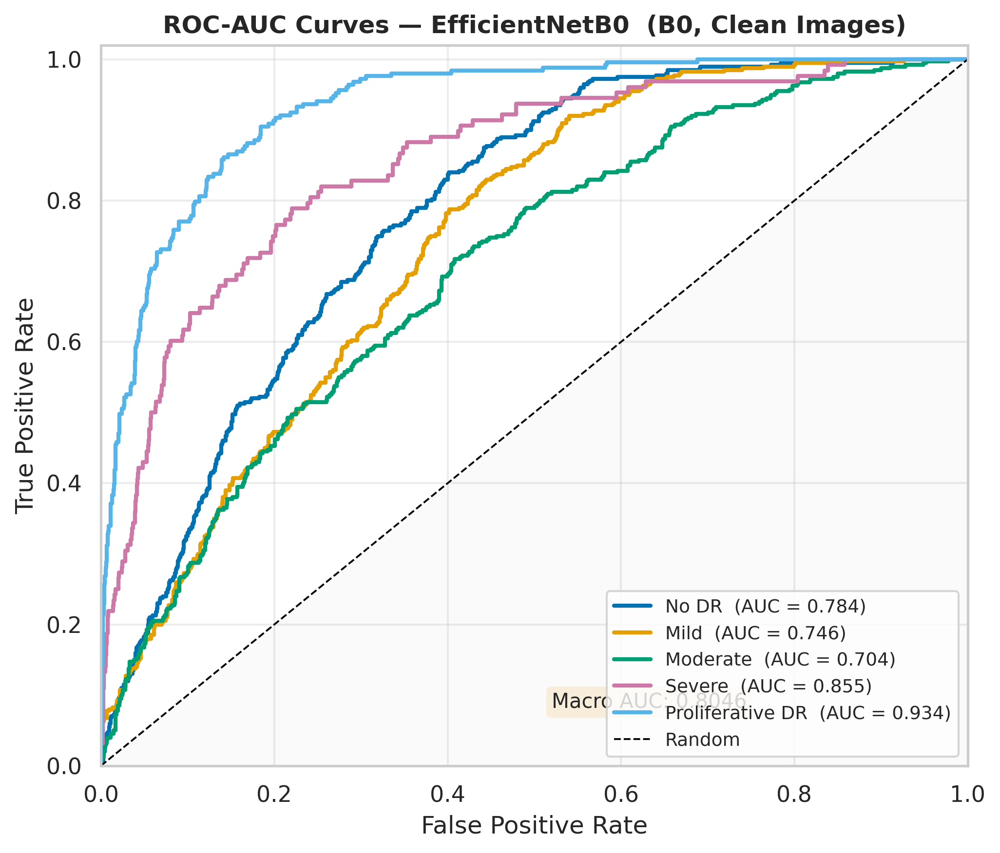

  EfficientNetB0  — per-class AUC:  No DR=0.784  Mild=0.746  Moderate=0.704  Severe=0.855  Proliferative DR=0.934
  Macro AUC: 0.8046



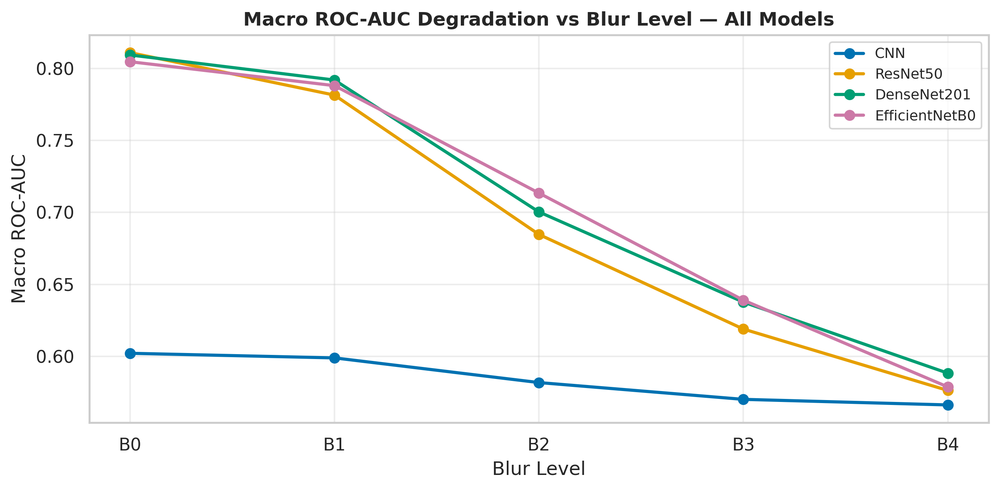

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Per-Class Sensitivity And Error Direction

This section checks whether blur affects some disease grades more than others, and whether models tend to under-grade or over-grade severity.


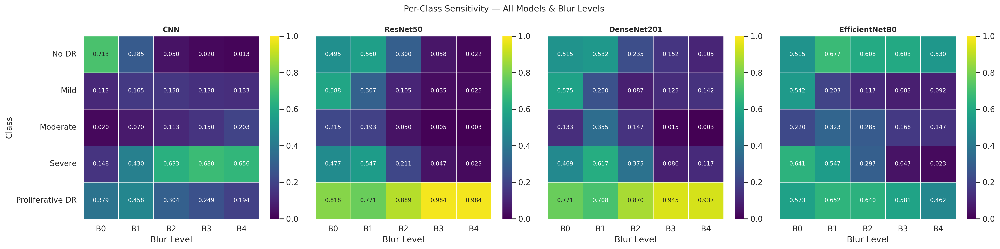


  Ordinal Error Rate  (|y_pred - y_true| >= 2)  at B0
  -------------------------------------------------------
  CNN                 adjacent=0.277  severe(≥2)=0.436
  ResNet50            adjacent=0.344  severe(≥2)=0.158
  DenseNet201         adjacent=0.371  severe(≥2)=0.158
  EfficientNetB0      adjacent=0.388  severe(≥2)=0.145


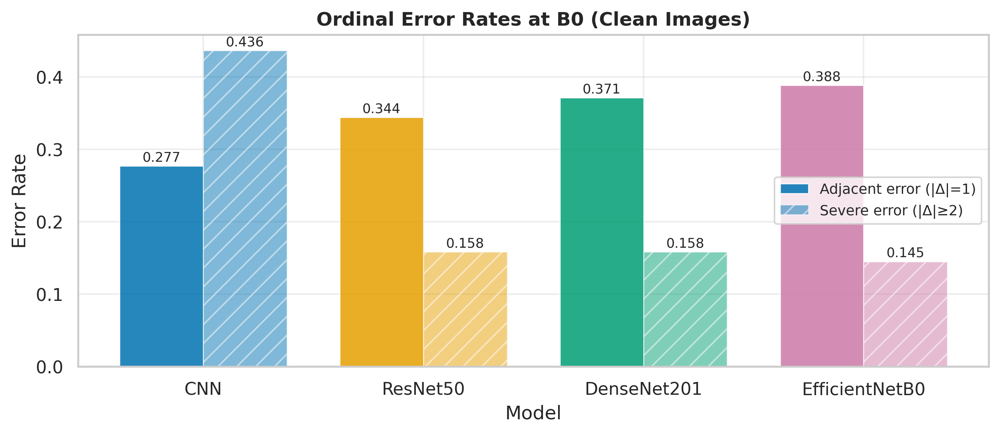

In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Grad-CAM Across Blur Levels

Grad-CAM highlights the image regions that most strongly support the model's final predicted class. The `viridis` colour map is used here: dark purple/blue areas contribute least to the prediction, green/yellow areas contribute more, and bright yellow areas have the strongest influence. The heatmap is overlaid on the fundus image, so a clinically useful pattern would usually keep attention on retinal structures rather than drifting to borders, background, or artefacts.

For each model, this section now displays one correctly classified B0 example and one misclassified B0 example when both are available. Comparing B0 through B4 shows whether the attended fundus regions remain stable as blur increases or whether the model shifts attention to different areas. The summary table reports the predicted label, confidence, normalised Grad-CAM centre drift from B0, and overlap of the most activated region with B0; larger drift and lower overlap suggest that blur changed the evidence used for the prediction.


Colour map guide: purple/blue = low contribution, green = moderate contribution, yellow = strongest contribution to the predicted class.


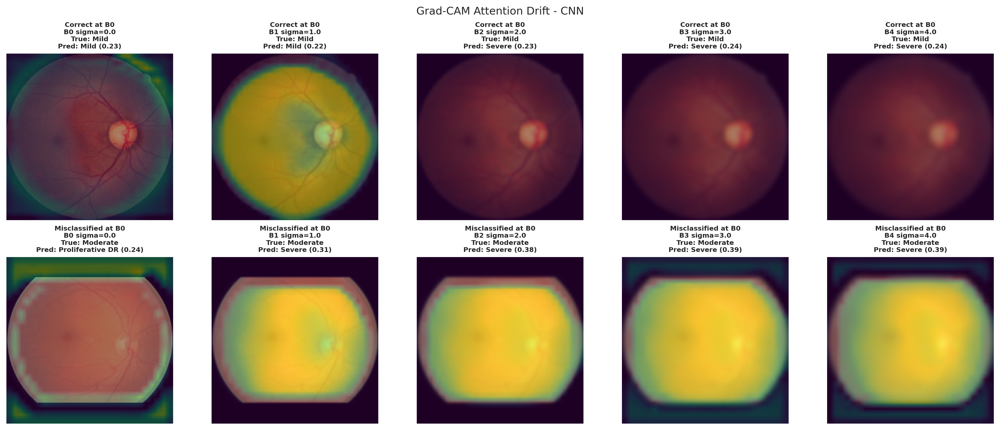

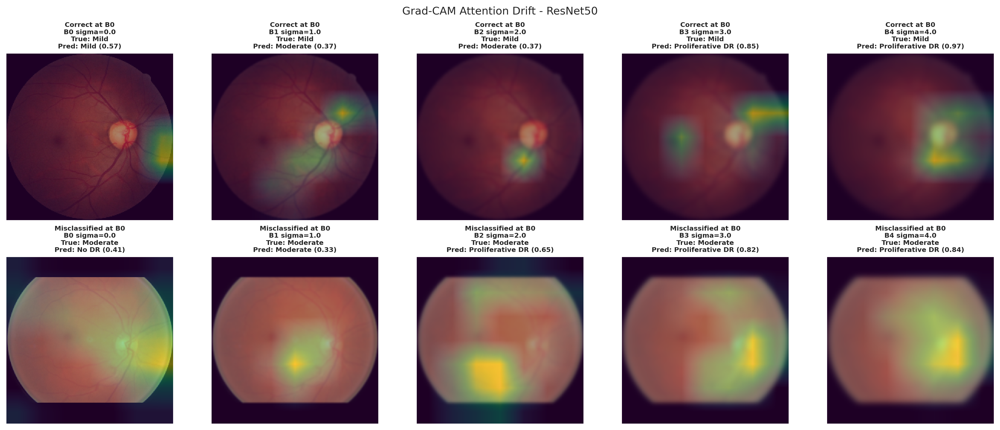

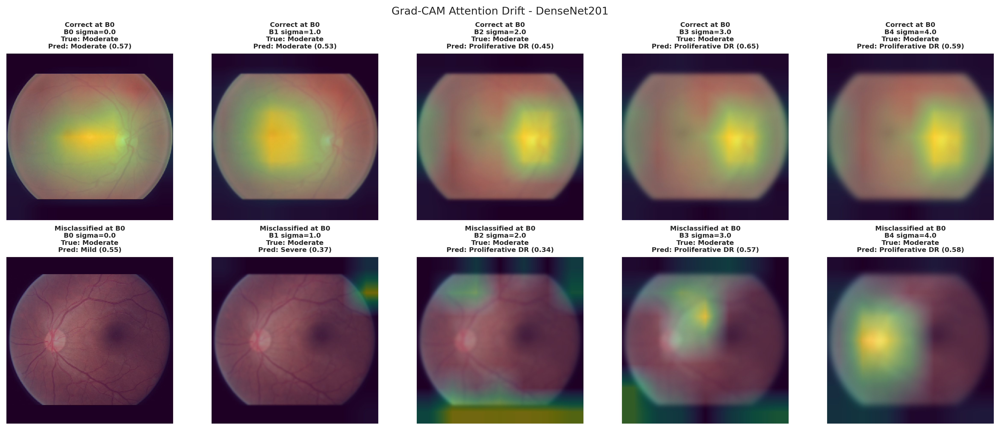

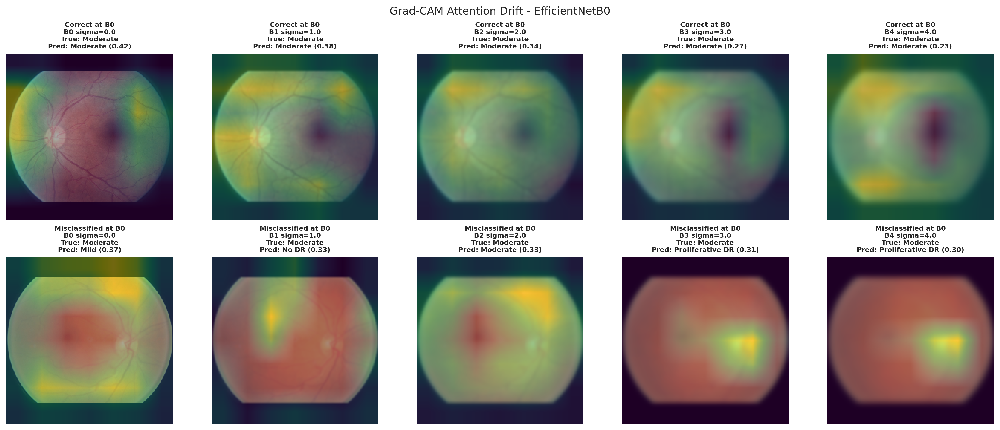

,model,case,file_name,true_class,blur,predicted_class,confidence,center_drift_vs_B0,top_region_overlap_vs_B0
0,CNN,Correct at B0,14902_right.jpg,Mild,B0,Mild,0.228,0.000,1.000
1,CNN,Correct at B0,14902_right.jpg,Mild,B1,Mild,0.219,0.048,0.000
2,CNN,Correct at B0,14902_right.jpg,Mild,B2,Severe,0.230,NaN,0.250
3,CNN,Correct at B0,14902_right.jpg,Mild,B3,Severe,0.237,NaN,0.250
4,CNN,Correct at B0,14902_right.jpg,Mild,B4,Severe,0.238,NaN,0.250
5,CNN,Misclassified at B0,26597_left.jpg,Moderate,B0,Proliferative DR,0.244,0.000,1.000
6,CNN,Misclassified at B0,26597_left.jpg,Moderate,B1,Severe,0.314,0.083,0.000
7,CNN,Misclassified at B0,26597_left.jpg,Moderate,B2,Severe,0.383,0.090,0.000
8,CNN,Misclassified at B0,26597_left.jpg,Moderate,B3,Severe,0.394,0.093,0.000
9,CNN,Misclassified at B0,26597_left.jpg,Moderate,B4,Severe,0.393,0.095,0.000


Interpretation guide: stable attention has low centre drift and high top-region overlap as blur increases.
Large drift or falling overlap means the model is using different fundus regions under blur, even if the predicted class remains the same.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

## Final Reflection

The final tables summarise clean-image performance and robustness. A modest B0 macro F1 is acceptable for this project because the main contribution is measuring relative degradation under controlled blur.


In [ ]:
# Code hidden: this research code is private. Only the outputs are shown.

,Model,Architecture / Pre-training,Key Hyperparameters,Parameters,Strengths,Selection Notes
0,CNN,Simple CNN from scratch,Conv blocks 32/64/128/256; Dense 128; dropout ...,Small,Plain reference model; easiest to interpret,Limited pilot tuning only; selected for valida...
1,ResNet50,ResNet50 - ImageNet,Dense 256 head; dropout 0.35; Adam lr=1e-3 the...,~25M,Skip connections; strong baseline; widely vali...,Top 50 percent of backbone unfrozen in phase 2
2,DenseNet201,DenseNet201 - ImageNet,Dense 256 head; dropout 0.35; Adam lr=1e-3 the...,~20M,Dense reuse; compact features; strong gradient...,Top 50 percent of backbone unfrozen in phase 2
3,EfficientNetB0,EfficientNetB0 - ImageNet,Dense 256 head; dropout 0.35; Adam lr=1e-3 the...,~5M,Compound scaling; strong efficiency-accuracy t...,Top 50 percent of backbone unfrozen in phase 2



  Test-set performance on clean images (B0):


,Model,Macro F1 (B0),QWK (B0),Macro AUC (B0)
0,ResNet50,0.4951,0.6804,0.8109
1,EfficientNetB0,0.4716,0.6881,0.8046
2,DenseNet201,0.4564,0.6861,0.8093
3,CNN,0.2211,0.2076,0.6022



  Best model: ResNet50
    Macro F1 : 0.4951
    QWK      : 0.6804
    Macro AUC: 0.8109

  Robustness ranking (Macro F1 relative retention at B4):


,Model,F1 Retention @ B4
0,CNN,0.749
1,EfficientNetB0,0.449
2,DenseNet201,0.365
3,ResNet50,0.169


Experiment complete. Main aim: compare relative degradation from B0 to B4, not maximise absolute accuracy.
FAST_MODE uses a reduced sample because of free Kaggle GPU limits, so results are indicative.
CNN hyperparameters were selected from limited pilot settings, not an exhaustive grid/random search.
ANOVA/t-tests are underpowered with only five class values per group and t-tests are not multiple-comparison corrected.
All figures at 300 DPI - viridis / Okabe-Ito palette.
